In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


1.Preparação e Merge dos dados

In [47]:
try:
    dados_mensal = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', sep=';', encoding='iso-8859-1')
    dados_dp = pd.read_csv('08.DP.csv', sep=',', encoding='utf-8')

    df_merge = dados_mensal.merge(dados_dp, left_on='cisp', right_on='codDP', how='left')
    # df_roubos.info()
    df_roubos = df_merge[['cisp', 'roubo_celular', 'roubo_transeunte', 'nome', 'regiao', 'mes', 'ano']]
    
    df_roubos.info()
    isna_roubos = df_roubos.isna().sum()
    df_roubos.fillna('Delegacia nao informada', inplace=True)
    
    df_roubo_celular = df_merge[['cisp', 'roubo_celular', 'nome', 'regiao', 'mes', 'ano']]  
    df_roubo_transeunte = df_merge[['cisp', 'roubo_transeunte', 'nome', 'regiao', 'mes', 'ano']]
       
    df_roubo_celular = df_roubo_celular.groupby(['regiao', 'mes', 'nome', 'ano'])[['roubo_celular']].sum().reset_index().sort_values(by='roubo_celular', ascending=False)

    df_roubo_transeunte = df_roubo_transeunte.groupby(['regiao', 'mes', 'nome', 'ano'])[['roubo_transeunte']].sum().reset_index().sort_values(by='roubo_transeunte', ascending=False)
    
except Exception as e:
    print(f'Erro ao carregar dados: {e}')
    exit(1)



<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   cisp              34848 non-null  int64
 1   roubo_celular     34848 non-null  int64
 2   roubo_transeunte  34848 non-null  int64
 3   nome              34787 non-null  str  
 4   regiao            34848 non-null  str  
 5   mes               34848 non-null  int64
 6   ano               34848 non-null  int64
dtypes: int64(5), str(2)
memory usage: 1.9 MB


2. Diagnostico Estatístico

In [48]:

array_celular = np.array(df_roubos['roubo_celular'])
array_transeunte = np.array(df_roubos['roubo_transeunte'])

# Medidas de Tendência Central

media_celular = np.mean(array_celular)
media_transeunte = np.mean(array_transeunte)

mediana_celular = np.median(array_celular)
mediana_transeunte = np.median(array_transeunte)

# moda = q2

# Medidas de Dispersão

variancia_celular = np.var(array_celular)
variancia_transeunte = np.var(array_transeunte)

desvio_padrao_celular = np.std(array_celular)
desvio_padrao_transeunte = np.std(array_transeunte) 

cv_celular = (desvio_padrao_celular / media_celular)
cv_transeunte = (desvio_padrao_transeunte / media_transeunte) 

# Posição e Limites

# Celular

min_celular = array_celular.min()
max_celular = array_celular.max()

amplitude_celular = max_celular - min_celular

q1_celular = np.quantile(array_celular, 0.25)
q2_celular = np.quantile(array_celular, 0.50)
q3_celular = np.quantile(array_celular, 0.75)

iqr_celular = q3_celular - q1_celular

lim_inferior_celular = q1_celular - 1.5 * iqr_celular

lim_superior_celular = q3_celular + 1.5 * iqr_celular

assimetria_celular = df_roubos ['roubo_celular'].skew()

kurt_celular = df_roubos['roubo_celular'].kurtosis()

delta_celular = media_celular - mediana_celular

# transeuntes

min_transeunte = array_transeunte.min()
max_transeunte = array_transeunte.max()

amplitude_transeunte = max_transeunte - min_transeunte

q1_transeunte = np.quantile(array_transeunte, 0.25)
q2_transeunte = np.quantile(array_transeunte, 0.50)
q3_transeunte = np.quantile(array_transeunte, 0.75)

iqr_transeunte = q3_transeunte - q1_transeunte

lim_inferior_transeunte = q1_transeunte - 1.5 * iqr_transeunte

lim_superior_transeunte = q3_transeunte + 1.5 * iqr_transeunte

assimetria_transeunte = df_roubos['roubo_transeunte'].skew()

kurt_transeunte = df_roubos['roubo_transeunte'].kurtosis()

delta_transeunte = media_transeunte - mediana_transeunte

Medidas de Roubo de Celulares

In [57]:

print(f' Media de Roubo de Celulares: {media_celular:.2f}')
print(f' Mediana de Roubo de Celulares: {mediana_celular}')
print(f' Variância de Roubo de Celulares: {variancia_celular:.2f}')
print(f' Desvio Padrão de Roubo de Celulares: {desvio_padrao_celular:.2f}')
print(f' Coeficiente de Variação de Roubo de Celulares: {cv_celular:.2f} ')
print(f' Mínimo de Roubo de Celulares: {min_celular}')  
print(f' Máximo de Roubo de Celulares: {max_celular}')
print(f' Q1 de Roubo de Celulares: {q1_celular:.2f}%')
print(f' Q2 de Roubo de Celulares: {q2_celular:.2f}%')
print(f' Q3 de Roubo de Celulares: {q3_celular:.2f}%')
print(f' IQR de Roubo de Celulares: {iqr_celular:.2f}')
print(f' Limite Inferior de Roubo de Celulares: {lim_inferior_celular:.2f}')    
print(f' Limite Superior de Roubo de Celulares: {lim_superior_celular:.2f}')
print(f' Amplitude de Roubo de Celulares: {amplitude_celular}')
print(f' Assimetria de Roubo de Celulares: {assimetria_celular:.2f}')
print(f' Curtose de Roubo de Celulares: {kurt_celular:.2f}')
print(f' Delta de Roubo de Celulares: {delta_celular:.2f}')


 Media de Roubo de Celulares: 7.97
 Mediana de Roubo de Celulares: 2.0
 Variância de Roubo de Celulares: 182.75
 Desvio Padrão de Roubo de Celulares: 13.52
 Coeficiente de Variação de Roubo de Celulares: 1.70 
 Mínimo de Roubo de Celulares: 0
 Máximo de Roubo de Celulares: 205
 Q1 de Roubo de Celulares: 0.00%
 Q2 de Roubo de Celulares: 2.00%
 Q3 de Roubo de Celulares: 11.00%
 IQR de Roubo de Celulares: 11.00
 Limite Inferior de Roubo de Celulares: -16.50
 Limite Superior de Roubo de Celulares: 27.50
 Amplitude de Roubo de Celulares: 205
 Assimetria de Roubo de Celulares: 3.37
 Curtose de Roubo de Celulares: 18.80
 Delta de Roubo de Celulares: 5.97


A análise dos dados de roubos de celulares revela que a distribuição dos roubos é altamente assimétrica e concentrada. A média (7,98) está significativamente acima da mediana (2), gerando um Delta positivo de 5,98, o que indica que a média está sendo inflada por alguns meses com valores extremamente elevados de ocorrência.

A elevada assimetria (3,37) e a curtose muito alta (18,77) confirmam a presença de eventos extremos na série, caracterizados por picos de roubos concentrados em determinados períodos e regiões. Esse comportamento sugere que o risco de roubo de celulares não é uniforme, tendo meses excepcionalmente violentos.

Medidas de Roubo a Transeuntes

In [56]:
print(f' Media de Roubo a Transeuntes: {media_transeunte:.2f}')
print(f' Mediana de Roubo a Transeuntes: {mediana_transeunte}')
print(f' Variância de Roubo a Transeuntes: {variancia_transeunte:.2f}')
print(f' Desvio Padrão de Roubo a Transeuntes: {desvio_padrao_transeunte:.2f}')
print(f' Coeficiente de Variação de Roubo a Transeuntes: {cv_transeunte:.2f}')
print(f' Mínimo de Roubo a Transeuntes: {min_transeunte}')
print(f' Máximo de Roubo a Transeuntes: {max_transeunte}')
print(f' Q1 de Roubo a Transeuntes: {q1_transeunte:.2f}%')
print(f' Q2 de Roubo a Transeuntes: {q2_transeunte:.2f}%')
print(f' Q3 de Roubo a Transeuntes: {q3_transeunte:.2f}%')
print(f' IQR de Roubo a Transeuntes: {iqr_transeunte:.2f}')
print(f' Limite Inferior de Roubo a Transeuntes: {lim_inferior_transeunte:.2f}')    
print(f' Limite Superior de Roubo a Transeuntes: {lim_superior_transeunte:.2f}')
print(f' Amplitude de Roubo a Transeuntes: {amplitude_transeunte}')
print(f' Assimetria de Roubo a Transeuntes: {assimetria_transeunte:.2f}')
print(f' Curtose de Roubo a Transeuntes: {kurt_transeunte:.2f}')
print(f' Delta de Roubo a Transeuntes: {delta_transeunte:.2f}')

 Media de Roubo a Transeuntes: 34.94
 Mediana de Roubo a Transeuntes: 11.0
 Variância de Roubo a Transeuntes: 2601.58
 Desvio Padrão de Roubo a Transeuntes: 51.01
 Coeficiente de Variação de Roubo a Transeuntes: 1.46
 Mínimo de Roubo a Transeuntes: 0
 Máximo de Roubo a Transeuntes: 504
 Q1 de Roubo a Transeuntes: 0.00%
 Q2 de Roubo a Transeuntes: 11.00%
 Q3 de Roubo a Transeuntes: 53.00%
 IQR de Roubo a Transeuntes: 53.00
 Limite Inferior de Roubo a Transeuntes: -79.50
 Limite Superior de Roubo a Transeuntes: 132.50
 Amplitude de Roubo a Transeuntes: 504
 Assimetria de Roubo a Transeuntes: 2.37
 Curtose de Roubo a Transeuntes: 7.79
 Delta de Roubo a Transeuntes: 23.94


A análise dos dados de roubos a transeuntes revela uma distribuição altamente assimétrica e concentrada. A média (35) encontra-se significativamente acima da mediana (11), gerando um Delta de 24, o que indica que a média da série é influenciada por meses com valores extremamente elevados de ocorrências.

A assimetria positiva (2,37) e a curtose elevada (7,77) confirmam a presença de eventos extremos, caracterizados por picos de criminalidade concentrados em determinados períodos e regiões. Esses resultados indicam que o risco de roubo a transeuntes não ocorre de forma homogênea, tendo picos de aumento de roubos. Isso significa que algumas áreas têm risco muito maior.

3. Identificação de Anomalias (Outliers)

In [51]:
# filtrar outliers
outliers_celular = df_roubos[df_roubos['roubo_celular'] > lim_superior_celular]

# criar array
array_outliers_celular = np.array(outliers_celular['roubo_celular'])

# contar por delegacia
outliers_por_dp = outliers_celular['nome'].value_counts().head(10).to_string()

print("Top 10 Delegacias com mais meses classificados como outliers:")
print(outliers_por_dp)


Top 10 Delegacias com mais meses classificados como outliers:
nome
059ª DP - Duque de Caxias        174
034ª DP - Bangu                  119
029ª DP - Madureira              113
023ª DP - Méier                  109
027ª DP - Vicente de Carvalho    104
064ª DP - São João de Meriti     103
033ª DP - Realengo                98
052ª DP - Nova Iguaçu             95
035ª DP - Campo Grande            90
021ª DP - Bonsucesso              83


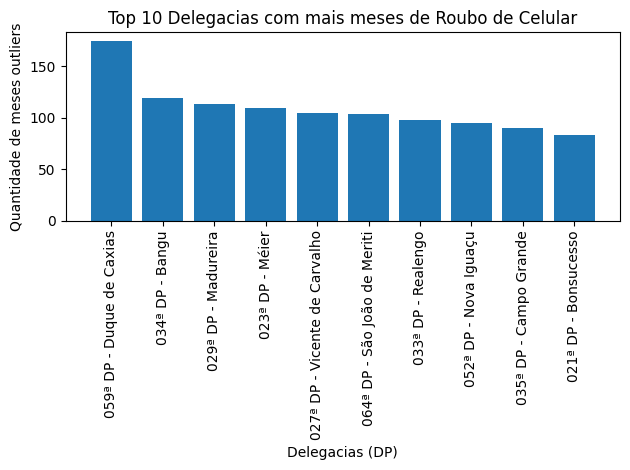

In [52]:
grafico_outliers = outliers_celular['nome'].value_counts().head(10)

plt.bar(grafico_outliers.index, grafico_outliers.values)

plt.xticks(rotation=90)
plt.xlabel('Delegacias (DP)')
plt.ylabel('Quantidade de meses outliers')
plt.title('Top 10 Delegacias com mais meses de Roubo de Celular')

plt.tight_layout()
plt.show()

4. Visualização de Dados

C:\Users\priscilla.goncalves\AppData\Local\Temp\ipykernel_19708\2442345581.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([array_celular, array_transeunte],labels=['Roubo Celular', 'Roubo Transeunte'],showfliers=True)


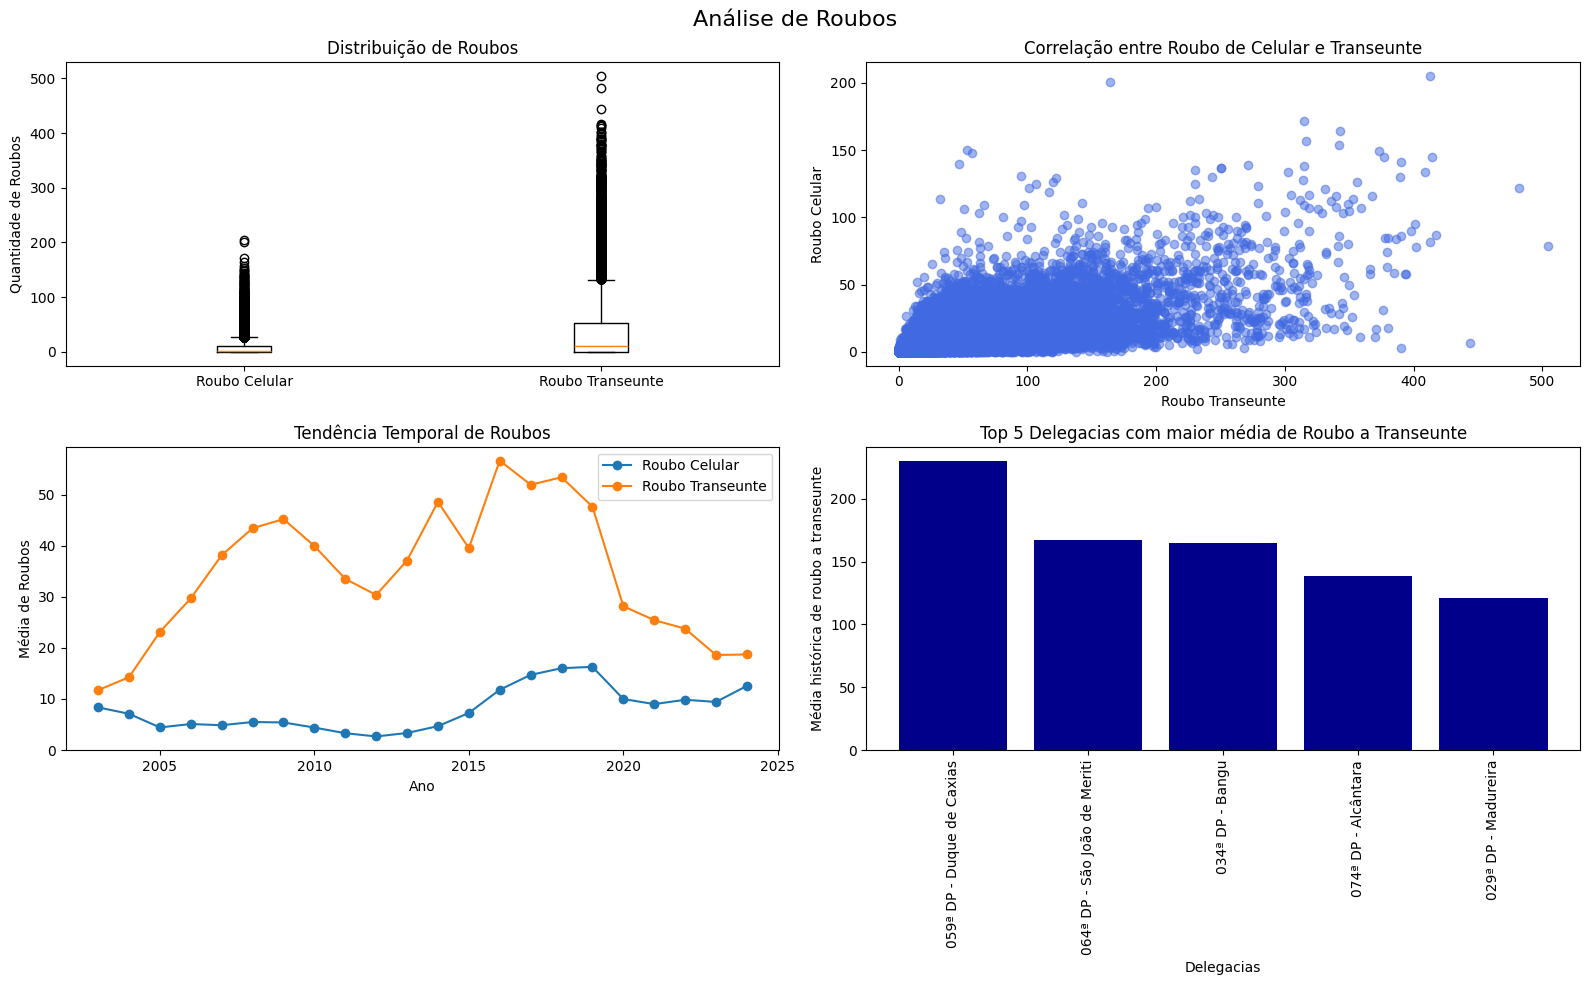

In [53]:
try:
   
    plt.subplots(2, 2, figsize=(16,10 ))
    plt.suptitle('Análise de Roubos', fontsize=16)

    plt.subplot(2, 2, 1)
    plt.boxplot([array_celular, array_transeunte],labels=['Roubo Celular', 'Roubo Transeunte'],showfliers=True)
    plt.title('Distribuição de Roubos')
    plt.ylabel('Quantidade de Roubos')

    plt.subplot(2, 2, 2)
    plt.scatter(array_transeunte, array_celular, color='royalblue', alpha=0.5)
    plt.xlabel('Roubo Transeunte')
    plt.ylabel('Roubo Celular')
    plt.title('Correlação entre Roubo de Celular e Transeunte')

    plt.subplot(2, 2, 3)
    tendencia = df_roubos.groupby('ano')[['roubo_celular','roubo_transeunte']].mean().reset_index()
    plt.plot(tendencia['ano'], tendencia['roubo_celular'], marker='o', label='Roubo Celular')
    plt.plot(tendencia['ano'], tendencia['roubo_transeunte'], marker='o', label='Roubo Transeunte')
    plt.xlabel('Ano')
    plt.ylabel('Média de Roubos')
    plt.title('Tendência Temporal de Roubos')
    plt.legend()

    plt.subplot(2, 2, 4)
    top5_dp = df_roubos.groupby('nome')['roubo_transeunte'].mean().sort_values(ascending=False).head(5)
    plt.bar(top5_dp.index, top5_dp.values, color = 'Darkblue')
    plt.xlabel('Delegacias')
    plt.ylabel('Média histórica de roubo a transeunte')
    plt.title('Top 5 Delegacias com maior média de Roubo a Transeunte')
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Erro na vizualização de dados: {e}')

Quadrante 2 - Gráfico de Dispersão (Scatter Plot):

1. Existe uma correlação linear forte?

Resposta: Existe correlação positiva entre roubo a transeunte e roubo de celular.

2. ○ Quando o roubo a transeunte sobe, o roubo de celular sobe na mesma proporção?

Resposta: Quando o roubo a transeunte aumenta, o roubo de celular tende a aumentar, mas não necessariamente na mesma proporção, indicando que a relação entre as variáveis não é perfeitamente linear. 

Quadrante 3 - Gráfico de Linha: 
1. O risco está aumentando ou diminuindo com o passar do tempo?

Resposta: O gráfico apresenta que o roubo de transeuntes esteve em aumento de 2005 a 2009, entrando em declinio em 2010 e novamente alcançando picos de aumento nos roubos até 2019. A partir de 2024, obervamos que entrou em declínio no número de roubos. Já o roubo de celular, oberva-se que não tiveram grandes picos, apenas aumento a partir de 2013, onde alcançou o índice máximo em 2019 e entrou em leve declínio até 2024. 
